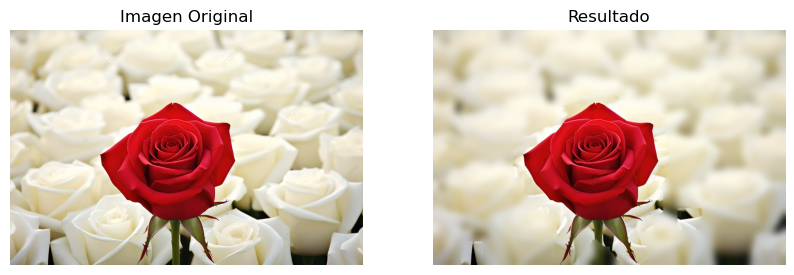

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('rosa.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mascara = cv2.dilate(cv2.bitwise_or(cv2.inRange(hsv,(0,100,80),(10,255,255)), cv2.inRange(hsv,(160,100,80),(180,255,255))), np.ones((20,20),np.uint8), iterations=3)
contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
neblina = cv2.GaussianBlur(img_rgb, (61,61), 0)
m = cv2.merge([mascara, mascara, mascara])
resultado = cv2.add(cv2.bitwise_and(img_rgb, m), cv2.bitwise_and(neblina, ~m))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title('Imagen Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(resultado); plt.title('Resultado'); plt.axis('off')
plt.show()


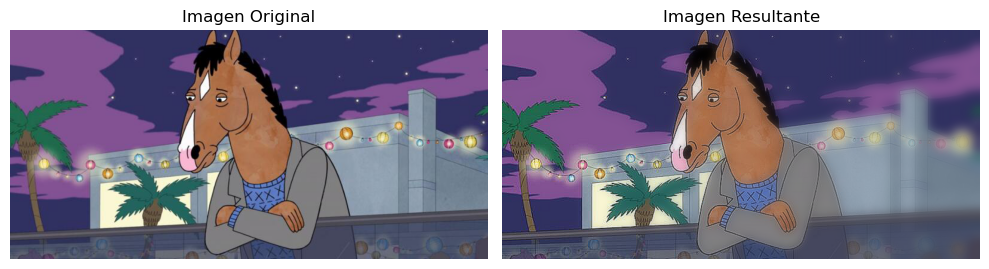

In [147]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]
kernel_sharp = np.array([[0, -1,  0],
                          [-1,  5, -1],
                          [0, -1,  0]])

img_sharp = cv2.filter2D(img_rgb, -1, kernel_sharp)
img_blur  = cv2.GaussianBlur(img_rgb, (51, 51), 0)
gradient = np.linspace(1.0, 0.0, w, dtype=np.float32)
mask = np.tile(gradient, (h, 1))[:, :, np.newaxis]

resultado = (img_sharp.astype(np.float32) * mask +
             img_blur.astype(np.float32) * (1 - mask)).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resultado)
plt.title('Imagen Resultante')
plt.axis('off')

plt.tight_layout()
plt.show()


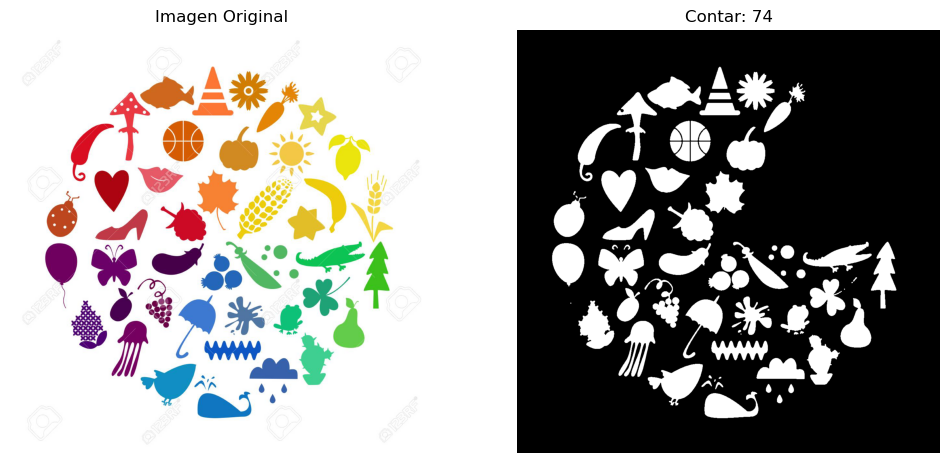

In [146]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Elementos.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)
_, binaria = cv2.threshold(blur, 180, 255, cv2.THRESH_BINARY_INV)
binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
validos = [c for c in contornos if cv2.contourArea(c) > 1]  
lienzo = np.zeros_like(gray)
cv2.drawContours(lienzo, validos, -1, 255, -1)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title('Imagen Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(lienzo, cmap='gray'); plt.title(f'Contar: {len(validos)}'); plt.axis('off')
plt.show()


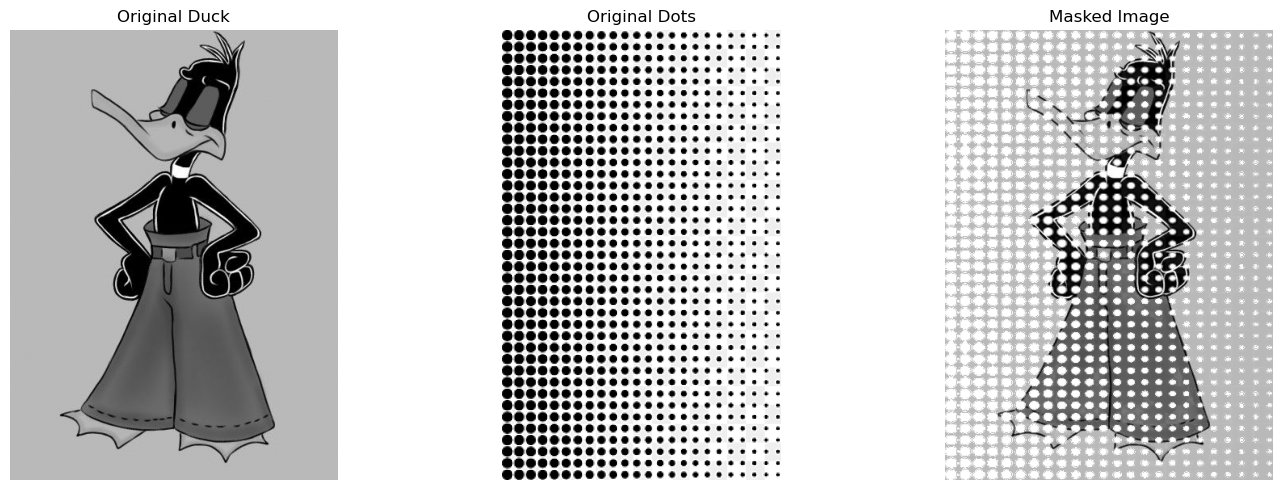

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

pato   = cv2.imread('pato.jpg',   cv2.IMREAD_GRAYSCALE)
puntos = cv2.imread('puntos.png', cv2.IMREAD_GRAYSCALE)


puntos_r = cv2.resize(puntos, (pato.shape[1], pato.shape[0]))
duck_inv = cv2.bitwise_not(pato)
masked_temp = cv2.bitwise_and(puntos_r, duck_inv)
masked = cv2.bitwise_not(masked_temp)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(pato, cmap='gray')
axs[0].set_title('Original Duck')
axs[0].axis('off')

axs[1].imshow(puntos, cmap='gray')
axs[1].set_title('Original Dots')
axs[1].axis('off')

axs[2].imshow(masked, cmap='gray')
axs[2].set_title('Masked Image')
axs[2].axis('off')

plt.tight_layout()
plt.show()

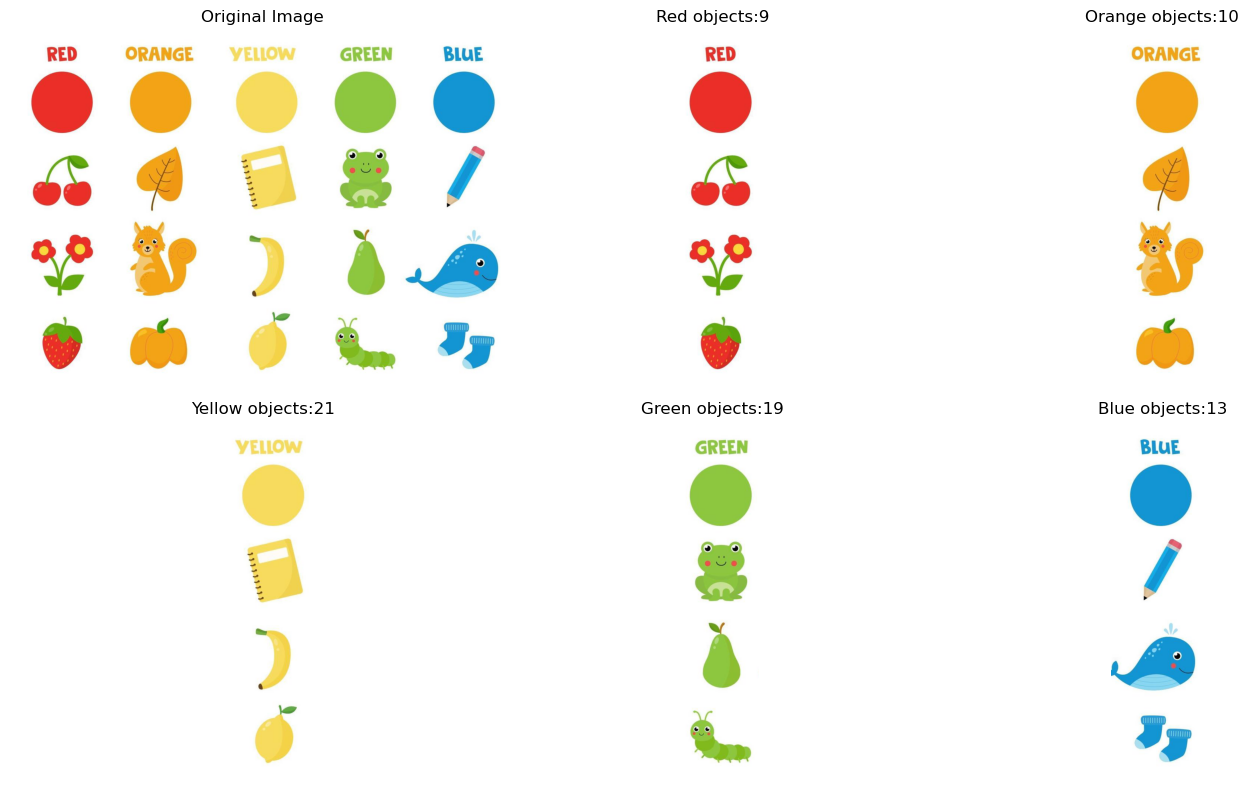

Conteo final:
  Red: 9
  Orange: 10
  Yellow: 21
  Green: 19
  Blue: 13


In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('colores.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

ancho = imagen_rgb.shape[1]
paso  = ancho // 5
margen = 30

columnas = {
    "Red":    imagen_rgb[:, 0*paso : 1*paso - margen],
    "Orange": imagen_rgb[:, 1*paso : 2*paso - margen],
    "Yellow": imagen_rgb[:, 2*paso : 3*paso - margen],
    "Green":  imagen_rgb[:, 3*paso : 4*paso - margen],
    "Blue":   imagen_rgb[:, 4*paso : ancho],
}

config = {
    "Red": {
        "rangos": [
            (np.array([0,   60, 50]),  np.array([9,   255, 255])),
            (np.array([170, 60, 50]),  np.array([180, 255, 255]))
        ],
        "min_area": 80,
        "kernel": np.ones((3, 3), np.uint8)
    },
    "Orange": {
        "rangos": [(np.array([9,  60, 50]),  np.array([22, 255, 255]))],
        "min_area": 80,
        "kernel": np.ones((3, 3), np.uint8)
    },
    "Yellow": {
        "rangos": [(np.array([15, 8, 40]),  np.array([40, 255, 255]))],
        "min_area": 17,
        "kernel": np.ones((2, 2), np.uint8)
    },
    "Green": {
        "rangos": [(np.array([30, 8, 15]),  np.array([100, 255, 255]))],
        "min_area": 22,
        "kernel": np.ones((2, 2), np.uint8)
    },
    "Blue": {
        "rangos": [(np.array([80, 8, 15]),  np.array([145, 255, 255]))],
        "min_area": 20,
        "kernel": np.ones((2, 2), np.uint8)
    },
}

conteos = {}

for color, col_rgb in columnas.items():
    col_hsv = cv2.cvtColor(col_rgb, cv2.COLOR_RGB2HSV)
    mask = np.zeros(col_hsv.shape[:2], dtype=np.uint8)
    for lower, upper in config[color]["rangos"]:
        mask = cv2.bitwise_or(mask, cv2.inRange(col_hsv, lower, upper))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, config[color]["kernel"], iterations=1)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    count = 0
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= config[color]["min_area"]:
            count += 1
    conteos[color] = count

plt.figure(figsize=(15, 8))

plt.subplot(231)
plt.imshow(imagen_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(232)
plt.imshow(columnas["Red"])
plt.title(f'Red objects:{conteos["Red"]}')
plt.axis('off')

plt.subplot(233)
plt.imshow(columnas["Orange"])
plt.title(f'Orange objects:{conteos["Orange"]}')
plt.axis('off')

plt.subplot(234)
plt.imshow(columnas["Yellow"])
plt.title(f'Yellow objects:{conteos["Yellow"]}')
plt.axis('off')

plt.subplot(235)
plt.imshow(columnas["Green"])
plt.title(f'Green objects:{conteos["Green"]}')
plt.axis('off')

plt.subplot(236)
plt.imshow(columnas["Blue"])
plt.title(f'Blue objects:{conteos["Blue"]}')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Conteo final:")
for color in ["Red", "Orange", "Yellow", "Green", "Blue"]:
    print(f"  {color}: {conteos[color]}")